# Análisis del Talento de los Autores en Goodreads

1. **Rating Medio en Goodreads**:
  
- Utiliza una fórmula ponderada que tenga en cuenta tanto el `average_rate` como el `review_count` para obtener una calificación más justa. Una fórmula comúnmente utilizada es la de la calificación bayesiana, que ajusta la calificación promedio en función del número de reseñas.   
- La fórmula es la siguiente:
  
  ```
  Weighted Rating = (v / (v + m)) * R + (m / (v + m)) * C
  ```
  
  Donde:
  - `R` es el `average_rate` del autor.
  - `v` es el `review_count` del autor.
  - `m` es el umbral mínimo de reseñas requerido para ser considerado (puede ser el promedio de reseñas de todos los autores).
  - `C` es el `average_rate` promedio de todos los autores.

Esta consulta calcula una calificación ponderada para cada autor en función de su calificación promedio y el número de reseñas que ha recibido. Luego, ordena a los autores por esta calificación ponderada y muestra los 10 mejores.

In [53]:
!pip install pymysql

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
from cartopy.io.shapereader import natural_earth
from sqlalchemy import create_engine
import configparser
import os

# Leer el archivo de configuración
config = configparser.ConfigParser()
config_file = '../goodreads_config.cfg'

if not os.path.isfile(config_file):
    raise FileNotFoundError(f"El archivo de configuración '{config_file}' no se encontró.")

config.read(config_file)

# Verificar si la sección 'database' existe en el archivo de configuración
if 'database' not in config:
    raise KeyError("La sección 'database' no se encontró en el archivo de configuración.")

# Obtener las credenciales de la base de datos
db_user = config['database']['user']
db_password = config['database']['password']
db_host = config['database']['host']
db_name = config['database']['database']

# Crear conexión a la base de datos
engine = create_engine(f'mysql+pymysql://{db_user}:{db_password}@{db_host}/{db_name}')

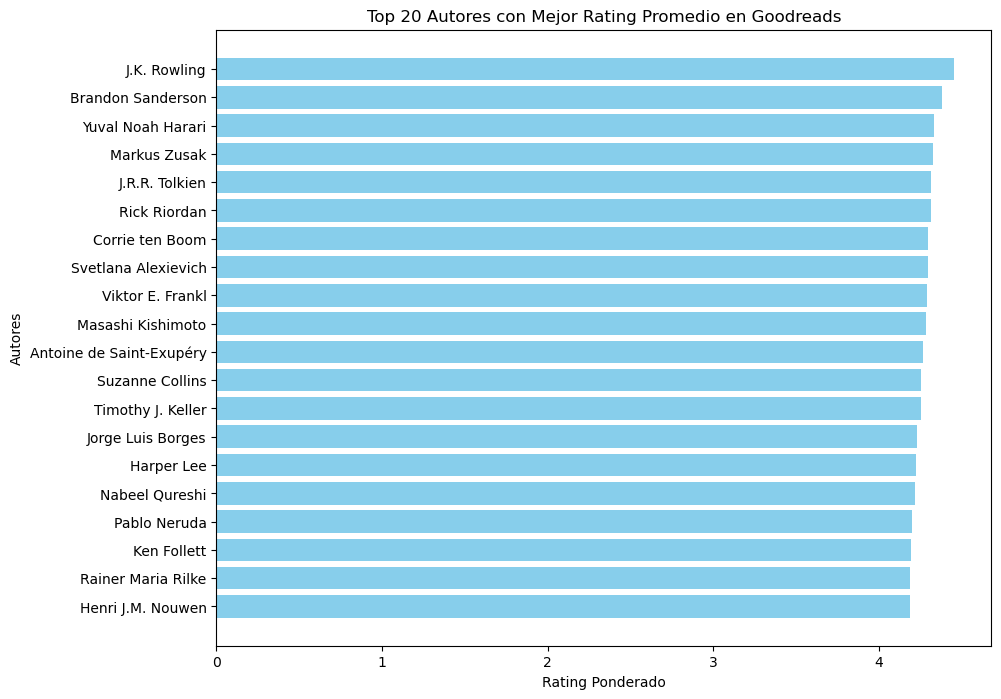

In [54]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS C, AVG(review_count) AS m
    FROM view_goodreads_authors_library
)
SELECT name, 
       average_rate, 
       review_count, 
       (review_count / (review_count + avg_stats.m)) * average_rate + (avg_stats.m / (review_count + avg_stats.m)) * avg_stats.C AS weighted_rating,
       CONCAT_WS(', ', original_hometown, country) AS procedencia
FROM view_goodreads_authors_library, avg_stats
WHERE (original_hometown IS NOT NULL AND original_hometown <> '') 
  AND (country IS NOT NULL AND country <> '')
ORDER BY weighted_rating DESC
LIMIT 20;
"""
df = pd.read_sql(query, engine)

# Crear la gráfica de barras horizontales
plt.figure(figsize=(10, 8))
plt.barh(df['name'], df['weighted_rating'], color='skyblue')
plt.xlabel('Rating Ponderado')
plt.ylabel('Autores')
plt.title('Top 20 Autores con Mejor Rating Promedio en Goodreads')
plt.gca().invert_yaxis()  # Invertir el eje y para que el autor con mejor rating esté en la parte superior
plt.savefig("../img/top20_authors.jpg", dpi=300, bbox_inches='tight')
plt.show()

2. **Número de Reseñas**:

- Estudia el campo `review_count` para ver cuántas reseñas han recibido los autores. Los autores con más reseñas pueden ser considerados más influyentes.

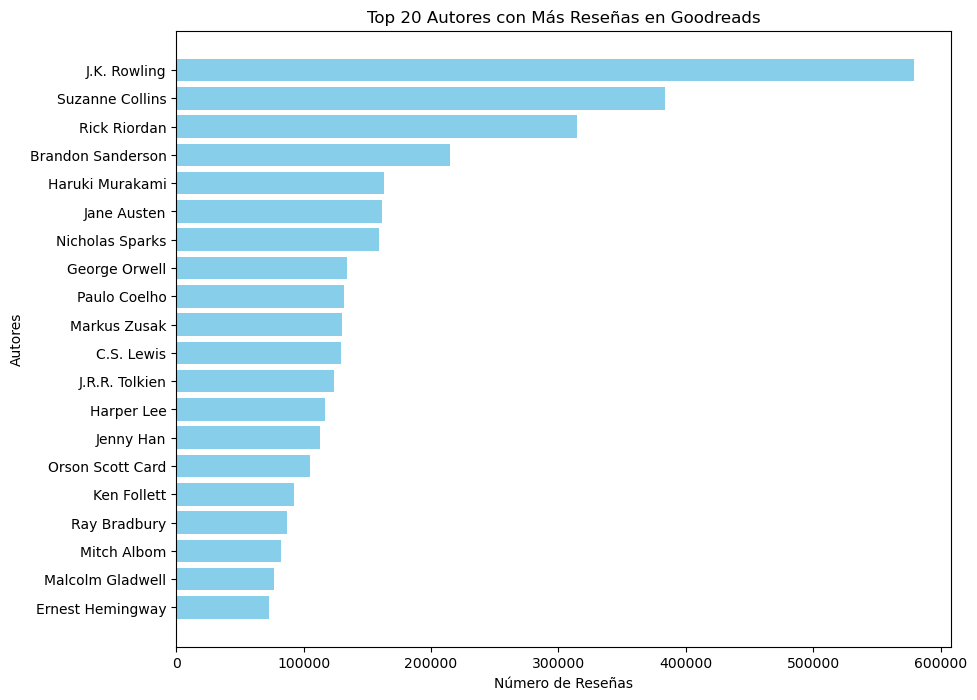

In [55]:
# Ejecutar la consulta SQL
query = """
SELECT name, review_count
FROM view_goodreads_authors_library
ORDER BY review_count DESC
LIMIT 20;
"""
df = pd.read_sql(query, engine)

# Crear la gráfica de barras horizontales
plt.figure(figsize=(10, 8))
plt.barh(df['name'], df['review_count'], color='skyblue')
plt.xlabel('Número de Reseñas')
plt.ylabel('Autores')
plt.title('Top 20 Autores con Más Reseñas en Goodreads')
plt.gca().invert_yaxis()  # Invertir el eje y para que el autor con más reseñas esté en la parte superior
plt.savefig("../img/top20_authors_reviews.jpg", dpi=300, bbox_inches='tight')
plt.show()

3. **Número de Fans**:

- Utiliza el campo `fan_count` para medir la popularidad de los autores.

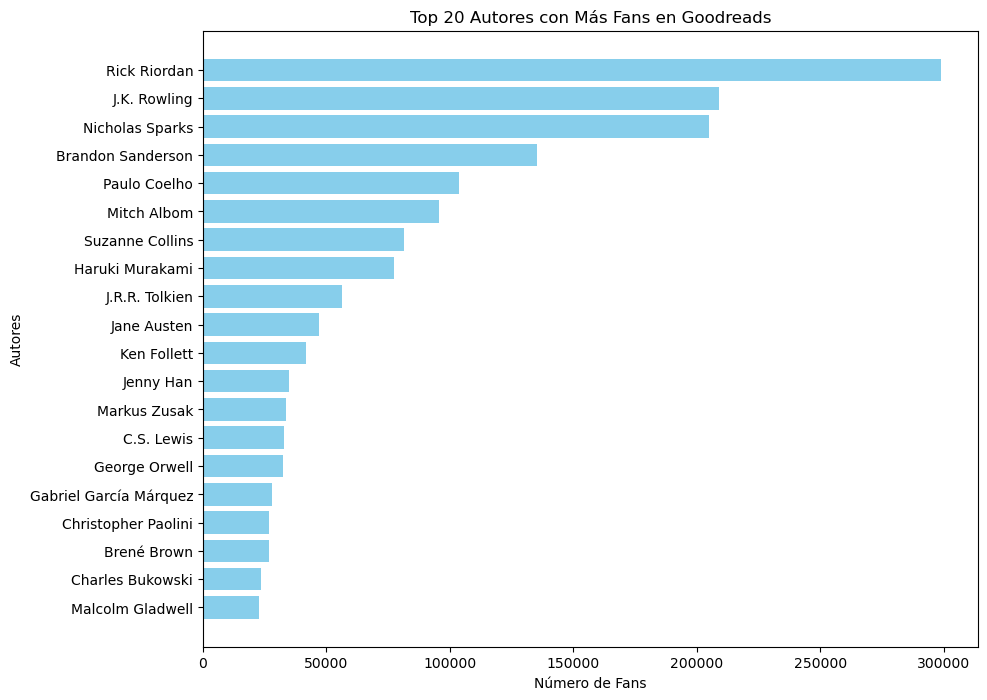

In [56]:
# Ejecutar la consulta SQL
query = """
SELECT name, fan_count
FROM view_goodreads_authors_library
ORDER BY fan_count DESC
LIMIT 20;
"""
df = pd.read_sql(query, engine)

# Crear la gráfica de barras horizontales
plt.figure(figsize=(10, 8))
plt.barh(df['name'], df['fan_count'], color='skyblue')
plt.xlabel('Número de Fans')
plt.ylabel('Autores')
plt.title('Top 20 Autores con Más Fans en Goodreads')
plt.gca().invert_yaxis()  # Invertir el eje y para que el autor con más fans esté en la parte superior
plt.savefig("../img/top20_authors_fans.jpg", dpi=300, bbox_inches='tight')
plt.show()

4. **Prolificidad del Autor**:

- Analiza el campo `workcount` para ver cuántos libros ha escrito cada autor.
- Considera también el número de páginas escritas si tienes esa información disponible.

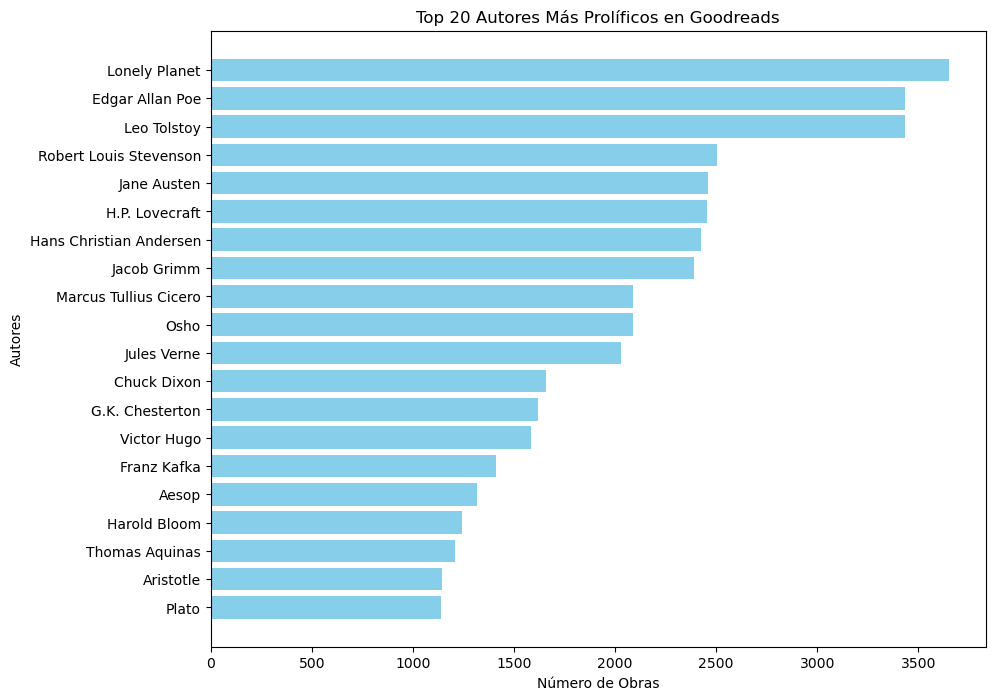

In [57]:
# Ejecutar la consulta SQL
query = """
SELECT name, workcount
FROM view_goodreads_authors_library
WHERE 
    name NOT IN ('NOT A BOOK', 'Anonymous', 'Unknown', 'Various', 'Memes')
    AND workcount < 5205
ORDER BY workcount DESC
LIMIT 20;
"""
df = pd.read_sql(query, engine)

# Crear la gráfica de barras horizontales
plt.figure(figsize=(10, 8))
plt.barh(df['name'], df['workcount'], color='skyblue')
plt.xlabel('Número de Obras')
plt.ylabel('Autores')
plt.title('Top 20 Autores Más Prolíficos en Goodreads')
plt.gca().invert_yaxis()  # Invertir el eje y para que el autor más prolífico esté en la parte superior
plt.savefig("../img/top20_authors_works.jpg", dpi=300, bbox_inches='tight')
plt.show()

5. **Influencia en Otros**:

- Utiliza el campo `influence` para ver si el autor ha influido en otros escritores o en la literatura en general.

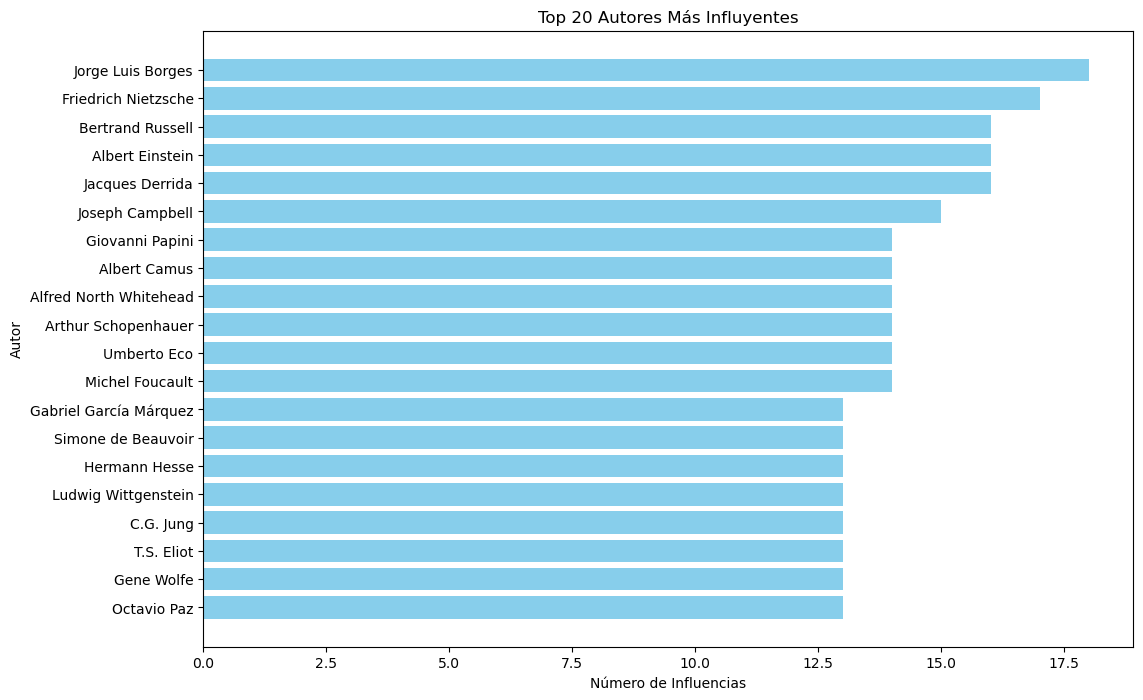

In [58]:
# Ejecutar la consulta SQL
query = """
SELECT name, influence,
       (LENGTH(influence) - LENGTH(REPLACE(influence, ',', '')) + 1) AS influence_count
FROM view_goodreads_authors_library
WHERE influence IS NOT NULL
ORDER BY influence_count DESC
LIMIT 20;
"""
df = pd.read_sql(query, engine)

# Crear la gráfica de barras
plt.figure(figsize=(12, 8))
plt.barh(df['name'], df['influence_count'], color='skyblue')
plt.xlabel('Número de Influencias')
plt.ylabel('Autor')
plt.title('Top 20 Autores Más Influyentes')
plt.gca().invert_yaxis()  # Invertir el eje y para que el autor con más influencias esté en la parte superior
plt.savefig("../img/top20_authors_influence.jpg", dpi=300, bbox_inches='tight')
plt.show()

6. **Clásicos o Best-Sellers**:

- Si tienes información sobre si un libro es un clásico o best-seller, puedes incluir esto en tu análisis. Esto podría requerir datos adicionales no presentes en `view_goodreads_authors_library`.

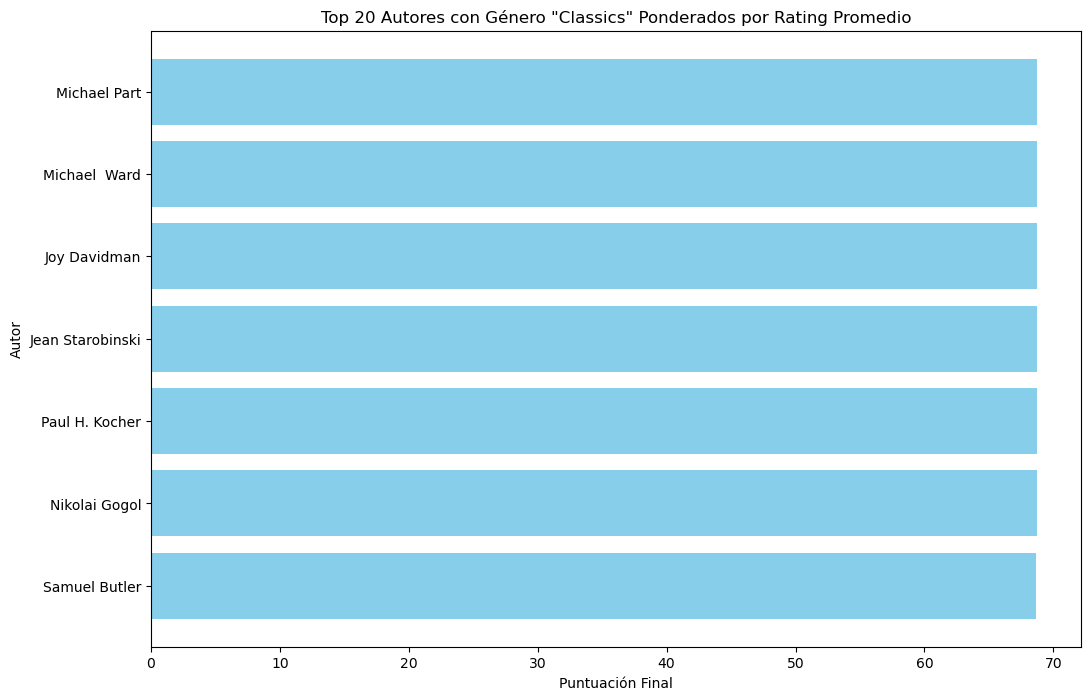

In [59]:
# Ejecutar la consulta SQL
query = """
WITH genre_stats AS (
    SELECT 
        author_id,
        SUM(
            CASE 
                WHEN genre LIKE '%%classic%%' THEN 1 
                ELSE 0 
            END
        ) AS genre_count
    FROM view_goodreads_authors_library
    GROUP BY author_id
),
avg_genre_stats AS (
    SELECT AVG(genre_count) AS avg_genre_count
    FROM genre_stats
),
avg_rating_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(rating_count) AS avg_rating_count
    FROM view_goodreads_authors_library
)
SELECT 
    a.name, 
    a.genre, 
    gs.genre_count,
    a.average_rate,
    a.rating_count,
    (gs.genre_count / ags.avg_genre_count) AS weighted_genre_score,
    (a.rating_count / (a.rating_count + ars.avg_rating_count)) * a.average_rate + (ars.avg_rating_count / (a.rating_count + ars.avg_rating_count)) * ars.avg_rating AS weighted_rating,
    ((gs.genre_count / ags.avg_genre_count) + ((a.rating_count / (a.rating_count + ars.avg_rating_count)) * a.average_rate + (ars.avg_rating_count / (a.rating_count + ars.avg_rating_count)) * ars.avg_rating)) / 2 AS final_score
FROM view_goodreads_authors_library a
JOIN genre_stats gs ON a.author_id = gs.author_id
JOIN avg_genre_stats ags
JOIN avg_rating_stats ars
WHERE gs.genre_count > 0
ORDER BY final_score DESC
LIMIT 20;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de barras
plt.figure(figsize=(12, 8))
plt.barh(df['name'], df['final_score'], color='skyblue')
plt.xlabel('Puntuación Final')
plt.ylabel('Autor')
plt.title('Top 20 Autores con Género "Classics" Ponderados por Rating Promedio')
plt.gca().invert_yaxis()  # Invertir el eje y para que el autor con la puntuación más alta esté en la parte superior
plt.savefig("../img/top20_authors_classics.jpg", dpi=300, bbox_inches='tight')
plt.show()

7. **Año de Nacimiento**:

- Analiza el campo `born` para ver si hay alguna correlación entre la edad del autor y su talento o popularidad.

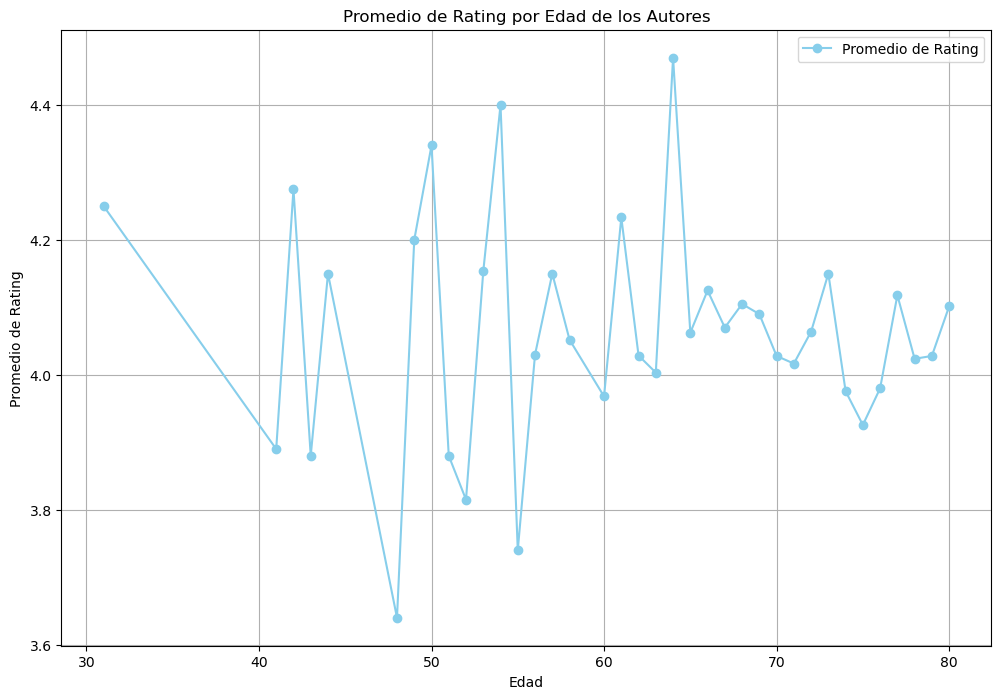

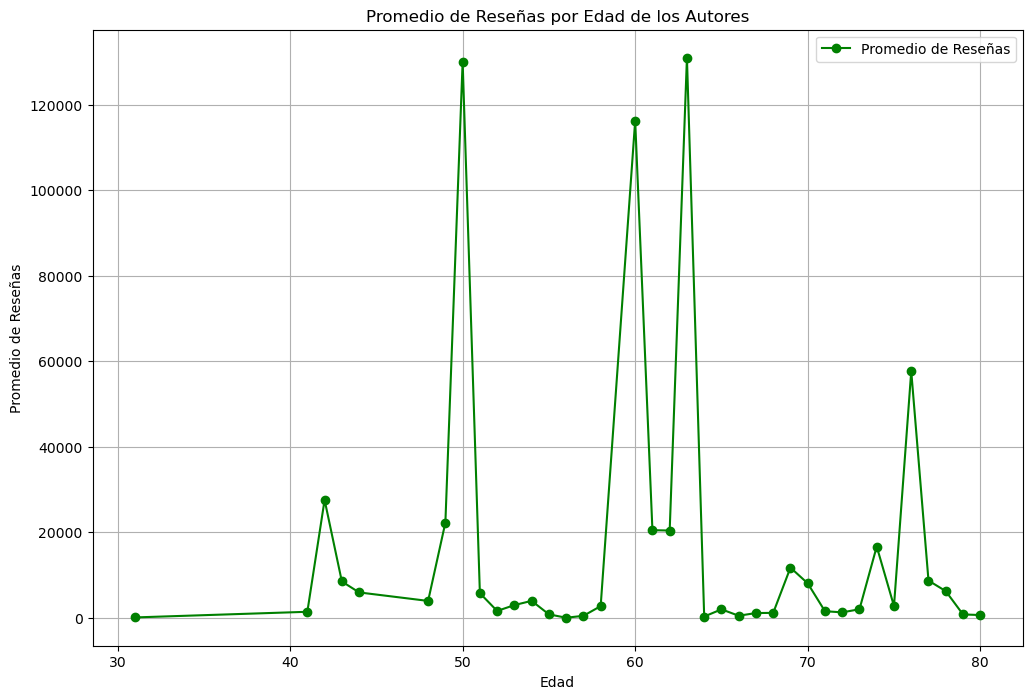

In [60]:
# Ejecutar la consulta SQL
query = """
WITH author_age AS (
    SELECT 
        author_id,
        name,
        YEAR(CURDATE()) - YEAR(born) AS age,
        average_rate,
        review_count
    FROM view_goodreads_authors_library
    WHERE born IS NOT NULL
    AND (YEAR(CURDATE()) - YEAR(born)) BETWEEN 13 AND 80
)
SELECT 
    age,
    AVG(average_rate) AS avg_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM author_age
GROUP BY age
ORDER BY age;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de líneas para la edad vs. promedio de rating
plt.figure(figsize=(12, 8))
plt.plot(df['age'], df['avg_rating'], marker='o', color='skyblue', label='Promedio de Rating')
plt.xlabel('Edad')
plt.ylabel('Promedio de Rating')
plt.title('Promedio de Rating por Edad de los Autores')
plt.legend()
plt.grid(True)
plt.savefig("../img/avg_rating_by_age.jpg", dpi=300, bbox_inches='tight')
plt.show()

# Crear la gráfica de líneas para la edad vs. promedio de reseñas
plt.figure(figsize=(12, 8))
plt.plot(df['age'], df['avg_review_count'], marker='o', color='green', label='Promedio de Reseñas')
plt.xlabel('Edad')
plt.ylabel('Promedio de Reseñas')
plt.title('Promedio de Reseñas por Edad de los Autores')
plt.legend()
plt.grid(True)
plt.savefig("../img/avg_reviews_by_age.jpg", dpi=300, bbox_inches='tight')
plt.show()

8. **Procedencia**:

- Utiliza los campos `original_hometown` y `country` para ver si hay patrones geográficos en los autores más talentosos.

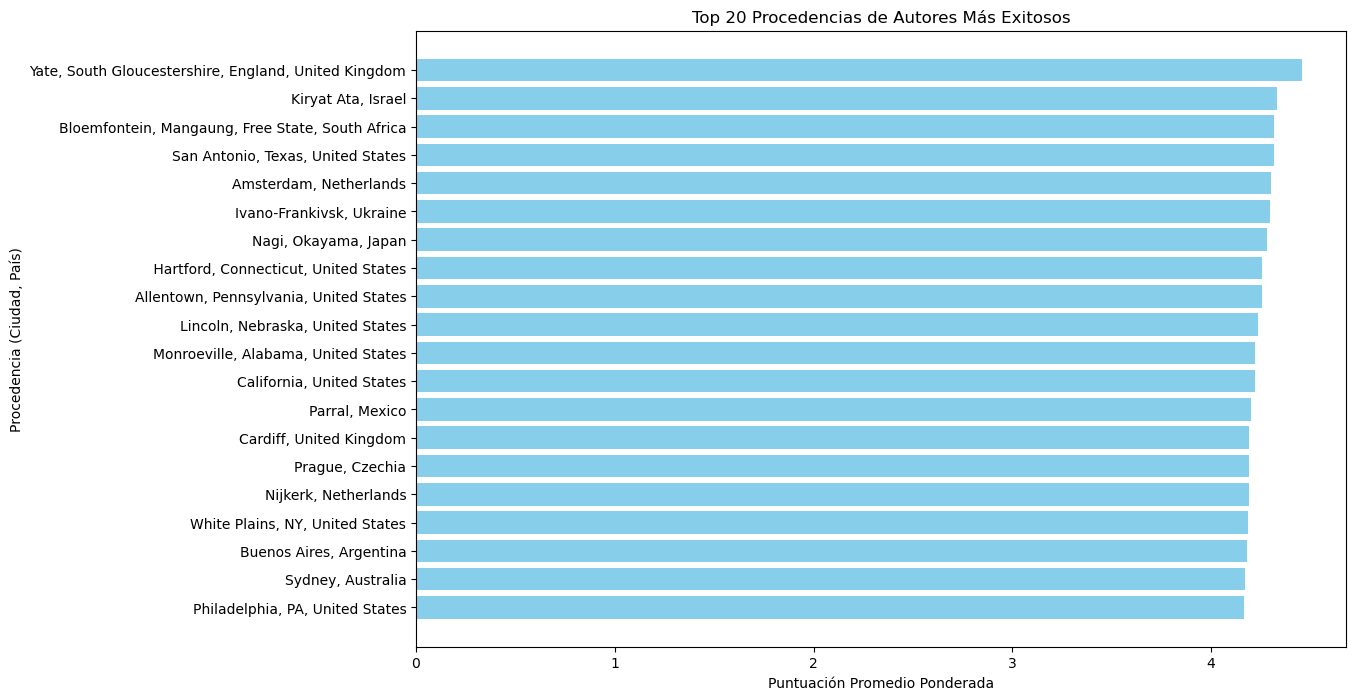

In [61]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
author_provenance AS (
    SELECT 
        original_hometown,
        country,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE original_hometown IS NOT NULL AND country IS NOT NULL
)
SELECT 
    original_hometown,
    country,
    AVG(weighted_rating) AS avg_weighted_rating,
    COUNT(*) AS author_count
FROM author_provenance
GROUP BY original_hometown, country
ORDER BY avg_weighted_rating DESC
LIMIT 20;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de barras
plt.figure(figsize=(12, 8))
plt.barh(df['original_hometown'] + ', ' + df['country'], df['avg_weighted_rating'], color='skyblue')
plt.xlabel('Puntuación Promedio Ponderada')
plt.ylabel('Procedencia (Ciudad, País)')
plt.title('Top 20 Procedencias de Autores Más Exitosos')
plt.gca().invert_yaxis()  # Invertir el eje y para que la procedencia con la puntuación más alta esté en la parte superior
plt.savefig("../img/top20_provenance.jpg", dpi=300, bbox_inches='tight')
plt.show()

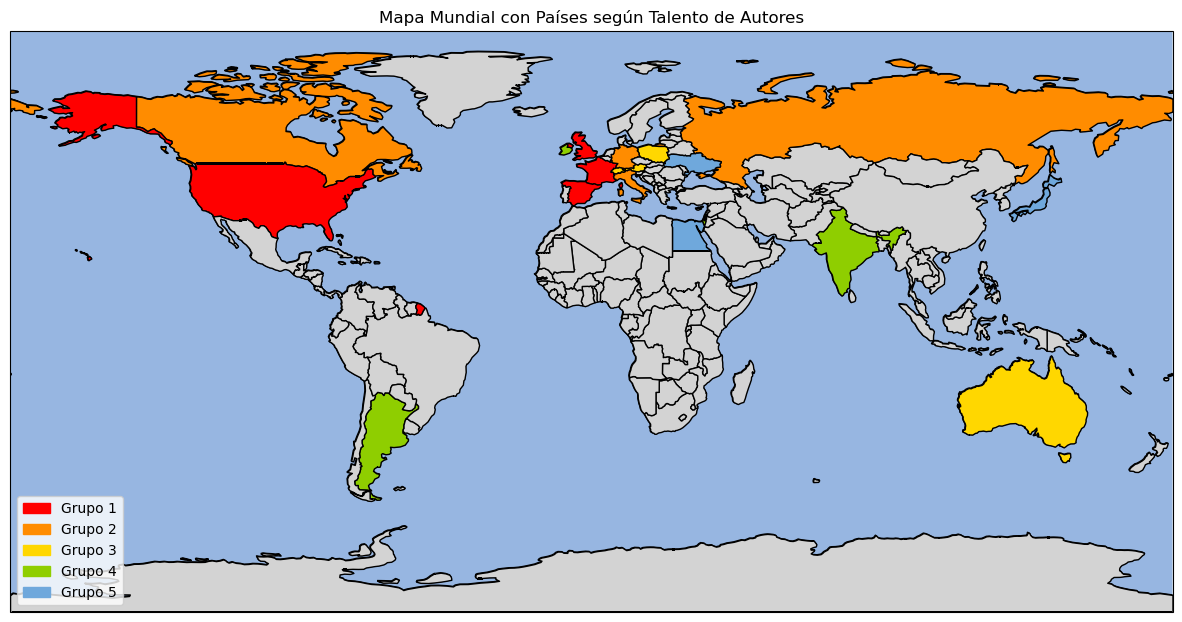

In [62]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
author_provenance AS (
    SELECT 
        country,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE country IS NOT NULL
)
SELECT 
    country,
    AVG(weighted_rating) AS avg_weighted_rating,
    COUNT(*) AS author_count
FROM author_provenance
GROUP BY country
ORDER BY author_count DESC
LIMIT 20;
"""

df = pd.read_sql(query, engine)

# Crear un diccionario con los países y sus colores según el promedio ponderado de rating
colors = ['#FF0000', '#FF8C00', '#FFD700', '#8fce00', '#6fa8dc']  # Rojo a amarillo claro
paises_colores = {}
for i, row in df.iterrows():
    color_index = i // 4
    if color_index < len(colors):
        paises_colores[row['country']] = colors[color_index]
    else:
        paises_colores[row['country']] = 'lightgrey'

# Ajustar nombres de países para que coincidan con el shapefile
country_name_mapping = {
    'United States': 'United States of America',
    # Añadir otros mapeos si es necesario
}

paises_colores = {country_name_mapping.get(k, k): v for k, v in paises_colores.items()}

# Crear el mapa usando Cartopy
fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax.add_feature(cfeature.COASTLINE)

# Cargar el shapefile de países
shpfilename = natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
reader = Reader(shpfilename)
countries = reader.records()

# Colorear los países según el diccionario
for country in countries:
    country_name = country.attributes['NAME']
    facecolor = paises_colores.get(country_name, 'lightgrey')
    ax.add_geometries([country.geometry], ccrs.PlateCarree(), facecolor=facecolor, edgecolor='black')

# Añadir leyenda
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors[i], label=f'Grupo {i+1}') for i in range(len(colors))]
plt.legend(handles=legend_handles, loc='lower left')

# Añadir título y mostrar el mapa
plt.title('Mapa Mundial con Países según Talento de Autores')
plt.savefig("../img/world_map.jpg", dpi=300, bbox_inches='tight')
plt.show()

#### En USA

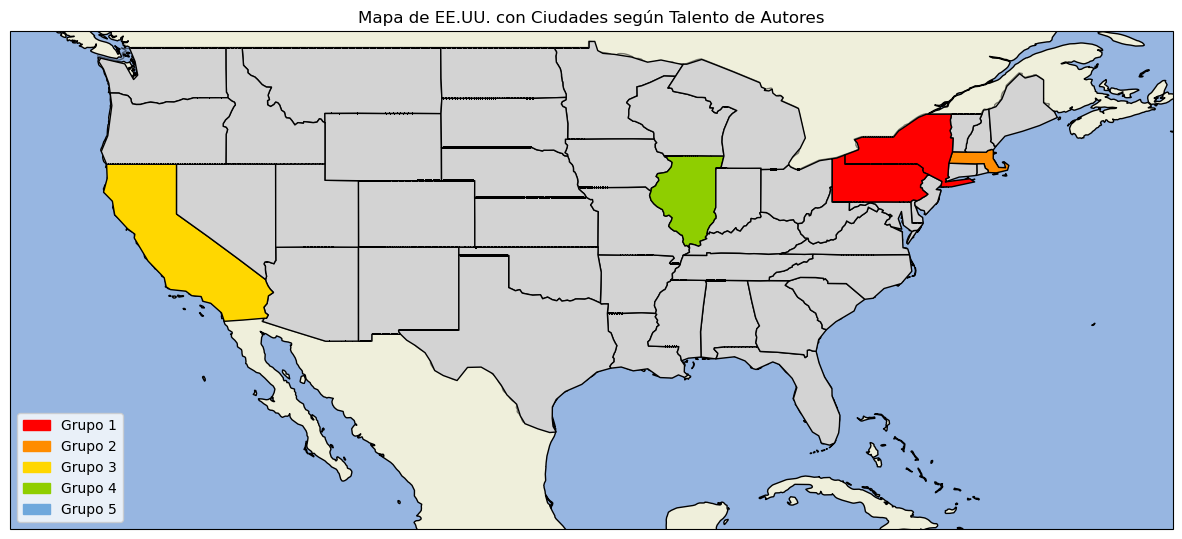

In [63]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
author_provenance AS (
    SELECT 
        CASE 
            WHEN original_hometown IN ('New York, NY', 'New York, New York', 'New York City, New York', 'New York City', 'New York', 'Brooklyn, NY', 'Brooklyn, New York', 'Brooklyn') THEN 'New York'
            WHEN original_hometown IN ('Los Angeles, California', 'Los Angeles') THEN 'Los Angeles'
            WHEN original_hometown IN ('Philadelphia, Pennsylvania', 'Philadelphia', 'Philadelphia, PA') THEN 'Philadelphia'
            WHEN original_hometown IN ('Chicago, Illinois', 'Chicago', 'Chicago, IL') THEN 'Chicago'
            WHEN original_hometown IN ('Boston, Massachusetts', 'Boston') THEN 'Boston'
            WHEN original_hometown IN ('San Francisco, California', 'San Francisco') THEN 'San Francisco'
            WHEN original_hometown IN ('Seattle, Washington', 'Seattle') THEN 'Seattle'
            WHEN original_hometown IN ('Detroit, Michigan', 'Detroit') THEN 'Detroit'
            WHEN original_hometown IN ('Washington, D.C.', 'Washington, DC') THEN 'Washington, D.C.'
            WHEN original_hometown IN ('Baltimore, Maryland', 'Baltimore') THEN 'Baltimore'
            WHEN original_hometown IN ('Cleveland, Ohio', 'Cleveland') THEN 'Cleveland'
            WHEN original_hometown IN ('San Diego, California', 'San Diego') THEN 'San Diego'
            WHEN original_hometown IN ('Minneapolis, Minnesota', 'Minneapolis') THEN 'Minneapolis'
            ELSE original_hometown
        END AS normalized_hometown,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE original_hometown IS NOT NULL AND country = 'United States'
)
SELECT 
    normalized_hometown AS original_hometown,
    AVG(weighted_rating) AS avg_weighted_rating,
    COUNT(*) AS author_count
FROM author_provenance
GROUP BY normalized_hometown
ORDER BY author_count DESC
LIMIT 20;
"""

df = pd.read_sql(query, engine)

# Crear un diccionario con los estados y sus colores según el promedio ponderado de rating
colors = ['#FF0000', '#FF8C00', '#FFD700', '#8fce00', '#6fa8dc']  # Rojo a amarillo claro
hometowns_colores = {}
for i, row in df.iterrows():
    color_index = i // 4
    if color_index < len(colors):
        hometowns_colores[row['original_hometown']] = colors[color_index]
    else:
        hometowns_colores[row['original_hometown']] = 'lightgrey'

# Ajustar nombres de ciudades y estados para que coincidan con el shapefile
city_state_mapping = {
    'Washington, D.C.': 'District of Columbia',
    'Seattle': 'Washington',
    'San Francisco': 'California',
    'Philadelphia': 'Pennsylvania',
    'New York': 'New York',
    'Los Angeles': 'California',
    'Detroit': 'Michigan',
    'Chicago': 'Illinois',
    'Boston': 'Massachusetts',
    'Baltimore': 'Maryland',
    'Cleveland': 'Ohio',
    'San Diego': 'California',
    'Minneapolis': 'Minnesota'
}

state_colores = {city_state_mapping.get(k, k): v for k, v in hometowns_colores.items()}

# Crear el mapa usando Cartopy
fig, ax = plt.subplots(1, 1, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-130, -60, 20, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax.add_feature(cfeature.COASTLINE)

# Cargar el shapefile de estados
shpfilename = natural_earth(resolution='110m', category='cultural', name='admin_1_states_provinces')
reader = Reader(shpfilename)
states = reader.records()

# Colorear los estados según el diccionario
for state in states:
    state_name = state.attributes['name']
    facecolor = state_colores.get(state_name, 'lightgrey')
    ax.add_geometries([state.geometry], ccrs.PlateCarree(), facecolor=facecolor, edgecolor='black')

# Añadir leyenda
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors[i], label=f'Grupo {i+1}') for i in range(len(colors))]
plt.legend(handles=legend_handles, loc='lower left')

# Añadir título y mostrar el mapa
plt.title('Mapa de EE.UU. con Ciudades según Talento de Autores')
plt.savefig("../img/usa_map.jpg", dpi=300, bbox_inches='tight')
plt.show()

9. **Sexo del Autor**:

- Analiza el campo `gender` para ver si hay diferencias en el talento o popularidad entre géneros.

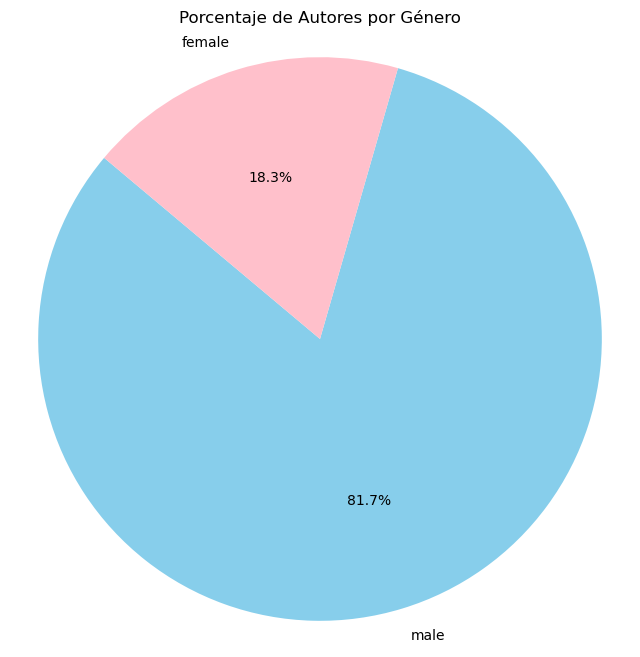

In [64]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
gender_stats AS (
    SELECT 
        gender,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE gender IS NOT NULL AND gender != 'unknown'
),
gender_counts AS (
    SELECT 
        gender,
        COUNT(*) AS author_count
    FROM gender_stats
    GROUP BY gender
),
total_count AS (
    SELECT SUM(author_count) AS total_authors
    FROM gender_counts
)
SELECT 
    g.gender,
    g.author_count,
    (g.author_count / t.total_authors) * 100 AS percentage
FROM gender_counts g, total_count t
ORDER BY g.author_count DESC;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de tarta
colors = ['skyblue', 'pink']
plt.figure(figsize=(8, 8))
plt.pie(df['percentage'], labels=df['gender'], colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Porcentaje de Autores por Género')
plt.axis('equal')  # Asegurar que el gráfico de tarta sea circular
plt.savefig("../img/gender.jpg", dpi=300, bbox_inches='tight')
plt.show()

10. **Tendencias Temporales**:

- Analiza el campo `died` para ver si hay tendencias en la popularidad de autores fallecidos versus autores vivos.

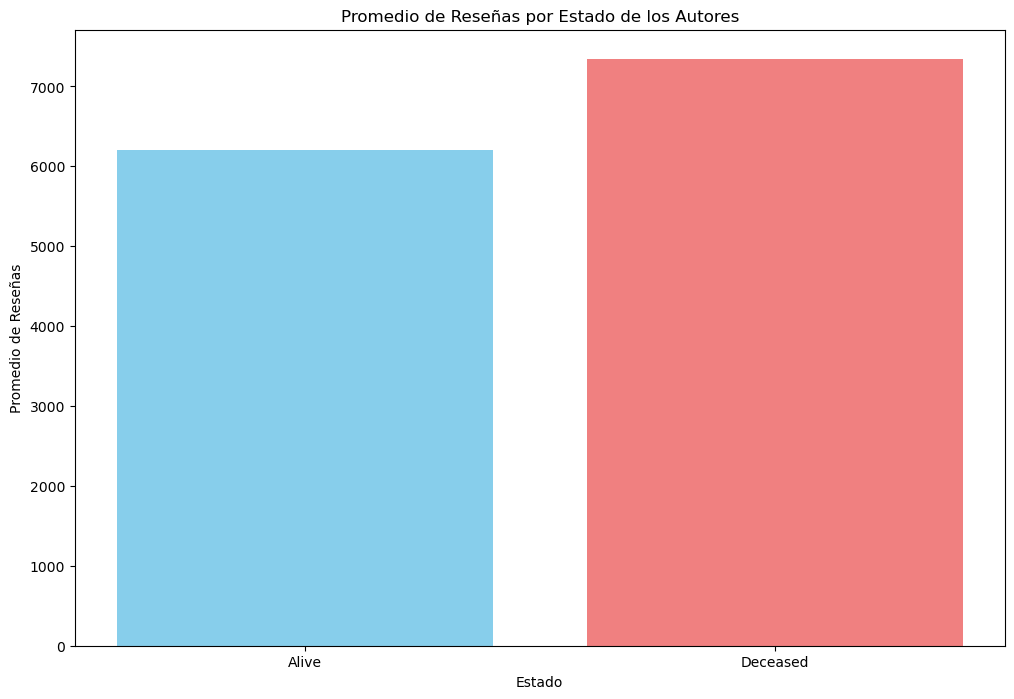

In [65]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
author_status AS (
    SELECT 
        CASE 
            WHEN died IS NULL THEN 'Alive'
            ELSE 'Deceased'
        END AS status,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
)
SELECT 
    status,
    AVG(weighted_rating) AS avg_weighted_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM author_status
GROUP BY status
ORDER BY status;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de barras para el promedio de reseñas
plt.figure(figsize=(12, 8))
plt.bar(df['status'], df['avg_review_count'], color=['skyblue', 'lightcoral'])
plt.xlabel('Estado')
plt.ylabel('Promedio de Reseñas')
plt.title('Promedio de Reseñas por Estado de los Autores')
plt.savefig("../img/avg_reviews_by_status.jpg", dpi=300, bbox_inches='tight')
plt.show()

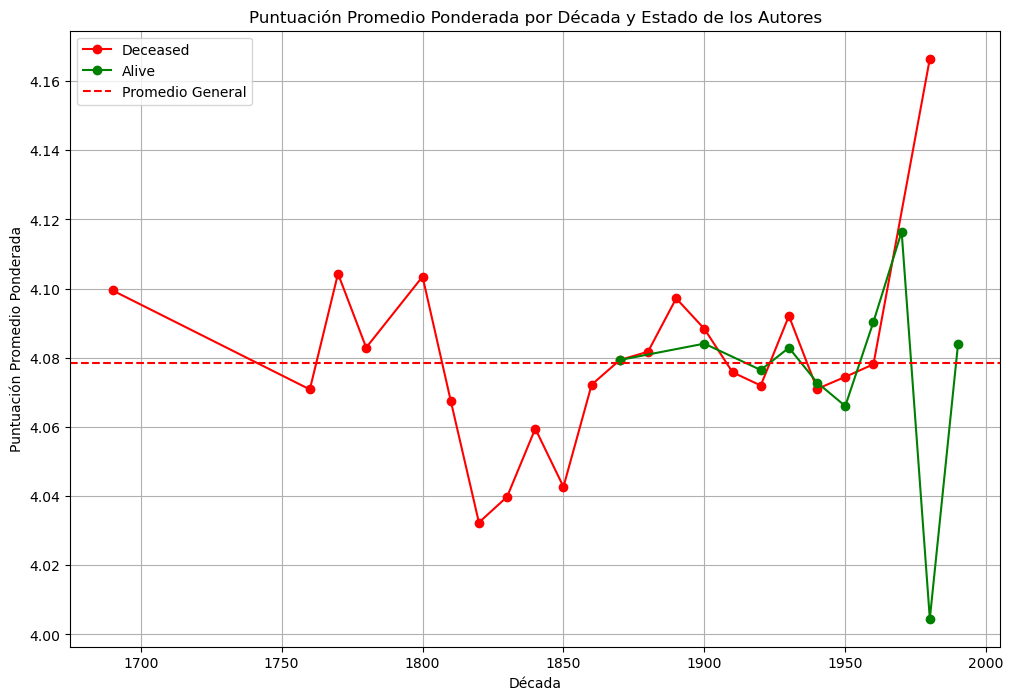

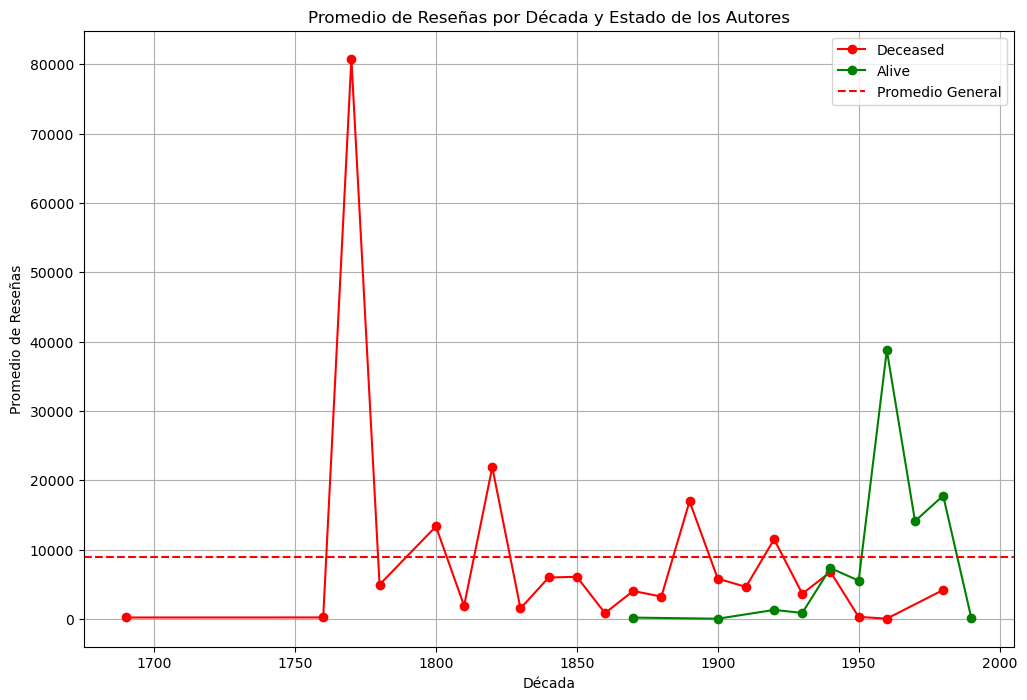

In [66]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
author_status AS (
    SELECT 
        CASE 
            WHEN died IS NULL THEN 'Alive'
            ELSE 'Deceased'
        END AS status,
        YEAR(born) AS birth_year,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE born IS NOT NULL
)
SELECT 
    status,
    FLOOR(birth_year / 10) * 10 AS decade,
    AVG(weighted_rating) AS avg_weighted_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM author_status
GROUP BY status, decade
ORDER BY decade;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de líneas para la puntuación promedio ponderada
plt.figure(figsize=(12, 8))
colors = {'Alive': 'green', 'Deceased': 'red'}
for status in df['status'].unique():
    subset = df[df['status'] == status]
    plt.plot(subset['decade'], subset['avg_weighted_rating'], marker='o', label=status, color=colors[status])

plt.axhline(y=df['avg_weighted_rating'].mean(), color='r', linestyle='--', label='Promedio General')
plt.xlabel('Década')
plt.ylabel('Puntuación Promedio Ponderada')
plt.title('Puntuación Promedio Ponderada por Década y Estado de los Autores')
plt.legend()
plt.grid(True)
plt.savefig("../img/avg_weighted_rating_by_decade.jpg", dpi=300, bbox_inches='tight')
plt.show()

# Crear la gráfica de líneas para el promedio de reseñas
plt.figure(figsize=(12, 8))
for status in df['status'].unique():
    subset = df[df['status'] == status]
    plt.plot(subset['decade'], subset['avg_review_count'], marker='o', label=status, color=colors[status])

plt.axhline(y=df['avg_review_count'].mean(), color='r', linestyle='--', label='Promedio General')
plt.xlabel('Década')
plt.ylabel('Promedio de Reseñas')
plt.title('Promedio de Reseñas por Década y Estado de los Autores')
plt.legend()
plt.grid(True)
plt.savefig("../img/avg_reviews_by_decade.jpg", dpi=300, bbox_inches='tight')
plt.show()

11. **Comparación de Géneros Literarios**:

- Utiliza el campo `genre` para ver si ciertos géneros literarios son más populares o tienen autores más talentosos.

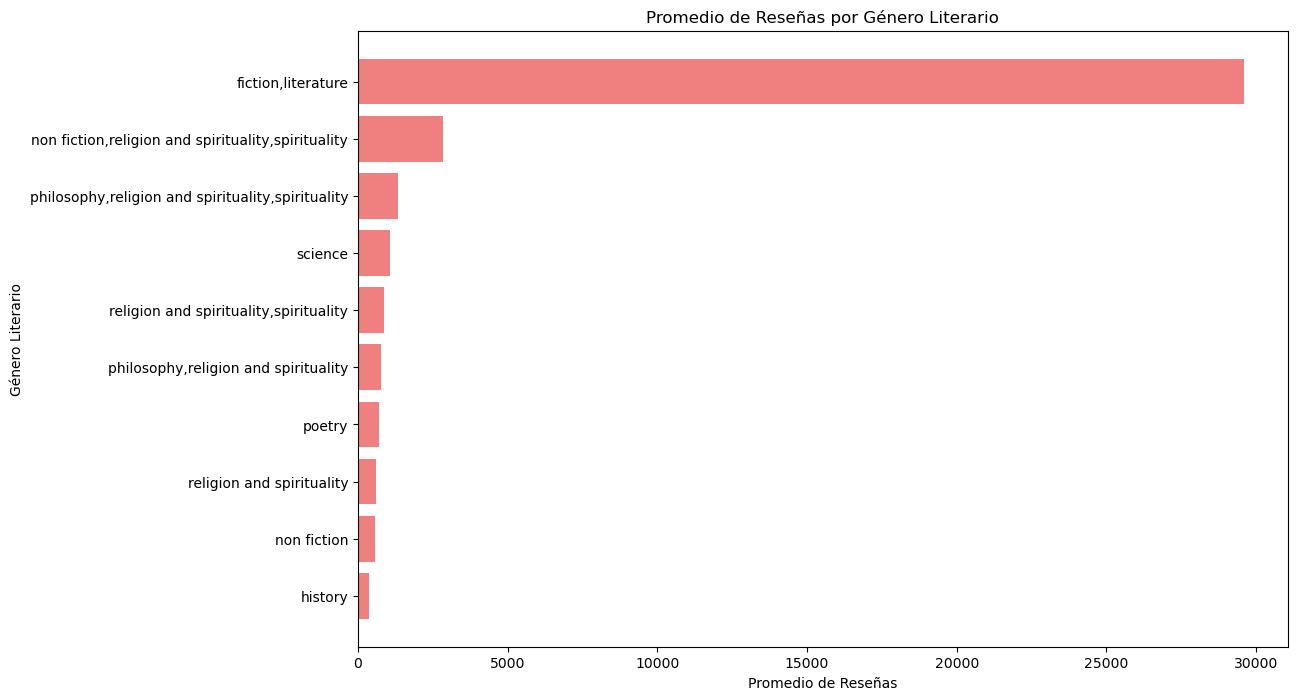

In [67]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
genre_stats AS (
    SELECT 
        genre,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE genre IS NOT NULL
)
SELECT 
    genre,
    AVG(weighted_rating) AS avg_weighted_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM genre_stats
GROUP BY genre
ORDER BY author_count DESC
LIMIT 10;
"""

df = pd.read_sql(query, engine)

# Ordenar el DataFrame por avg_weighted_rating de mayor a menor
df_weighted_rating = df.sort_values(by='avg_weighted_rating', ascending=False)

# Ordenar el DataFrame por avg_review_count de mayor a menor
df_review_count = df.sort_values(by='avg_review_count', ascending=False)

# Crear la gráfica de barras para el promedio de reseñas
plt.figure(figsize=(12, 8))
plt.barh(df_review_count['genre'], df_review_count['avg_review_count'], color='lightcoral')
plt.xlabel('Promedio de Reseñas')
plt.ylabel('Género Literario')
plt.title('Promedio de Reseñas por Género Literario')
plt.gca().invert_yaxis()  # Invertir el eje y para que el género con el promedio de reseñas más alto esté en la parte superior
plt.savefig("../img/avg_reviews_by_genre.jpg", dpi=300, bbox_inches='tight')
plt.show()

1.  **Presencia en Redes Sociales**:
    - Utiliza los campos `website` y `twitter` para ver si los autores con una mayor presencia en línea tienen más éxito.

    - Utiliza el campo `image_url` para ver si los autores con imágenes de perfil tienen más éxito, lo que podría indicar una mejor estrategia de marketing.

    - Analiza el campo `about` para ver si la longitud o el contenido de la biografía del autor correlaciona con su éxito.

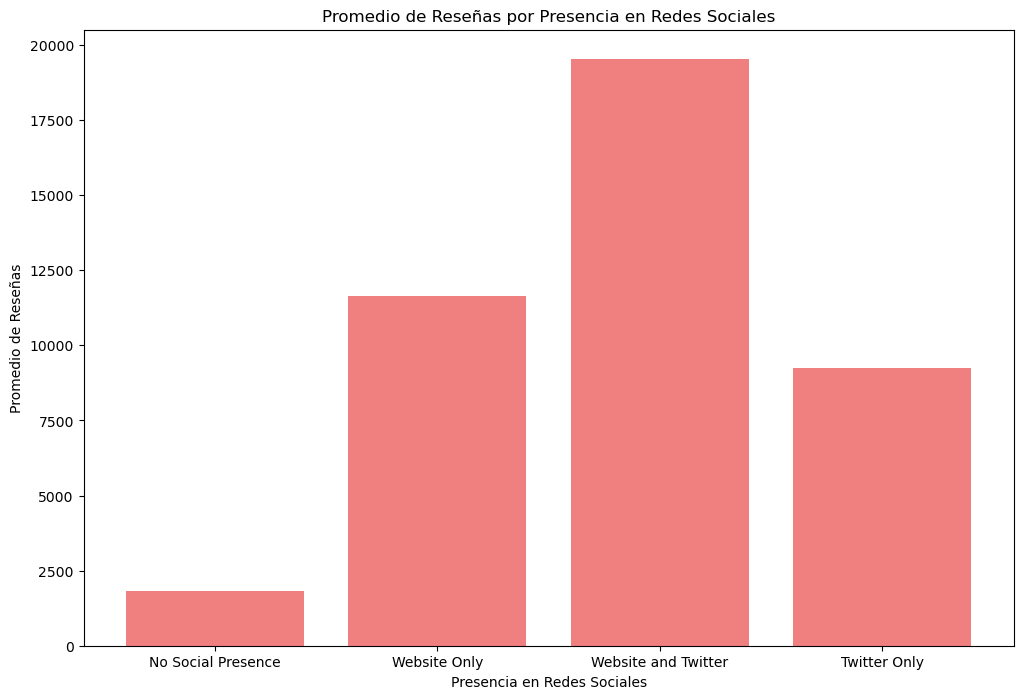

In [68]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
social_presence AS (
    SELECT 
        CASE 
            WHEN website IS NOT NULL AND twitter IS NOT NULL THEN 'Website and Twitter'
            WHEN website IS NOT NULL THEN 'Website Only'
            WHEN twitter IS NOT NULL THEN 'Twitter Only'
            ELSE 'No Social Presence'
        END AS social_presence,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
)
SELECT 
    social_presence,
    AVG(weighted_rating) AS avg_weighted_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM social_presence
GROUP BY social_presence
ORDER BY author_count DESC;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de barras para el promedio de reseñas
plt.figure(figsize=(12, 8))
plt.bar(df['social_presence'], df['avg_review_count'], color='lightcoral')
plt.xlabel('Presencia en Redes Sociales')
plt.ylabel('Promedio de Reseñas')
plt.title('Promedio de Reseñas por Presencia en Redes Sociales')
plt.savefig("../img/avg_reviews_by_social.jpg", dpi=300, bbox_inches='tight')
plt.show()

  image_presence  avg_weighted_rating  avg_review_count  author_count
0      Has Image             4.079442         6575.6243           937


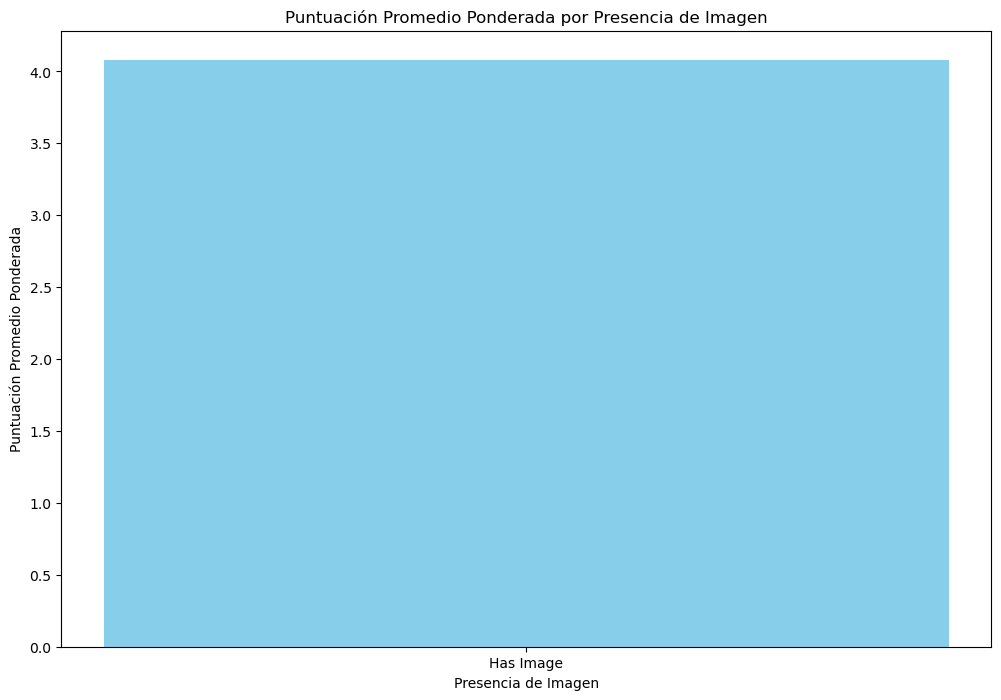

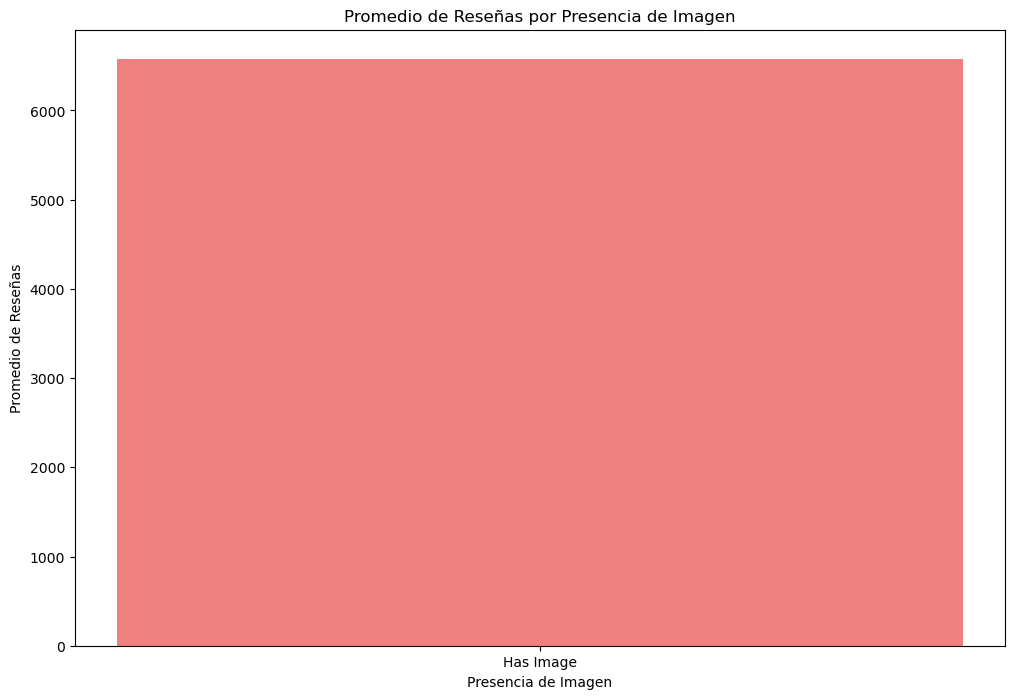

In [69]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
image_presence AS (
    SELECT 
        CASE 
            WHEN image_url IS NOT NULL THEN 'Has Image'
            ELSE 'No Image'
        END AS image_presence,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
)
SELECT 
    image_presence,
    AVG(weighted_rating) AS avg_weighted_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM image_presence
GROUP BY image_presence
ORDER BY author_count DESC;
"""

df = pd.read_sql(query, engine)

# Verificar el contenido del DataFrame
print(df)

# Crear la gráfica de barras para la puntuación promedio ponderada
plt.figure(figsize=(12, 8))
plt.bar(df['image_presence'], df['avg_weighted_rating'], color='skyblue')
plt.xlabel('Presencia de Imagen')
plt.ylabel('Puntuación Promedio Ponderada')
plt.title('Puntuación Promedio Ponderada por Presencia de Imagen')
plt.show()

# Crear la gráfica de barras para el promedio de reseñas
plt.figure(figsize=(12, 8))
plt.bar(df['image_presence'], df['avg_review_count'], color='lightcoral')
plt.xlabel('Presencia de Imagen')
plt.ylabel('Promedio de Reseñas')
plt.title('Promedio de Reseñas por Presencia de Imagen')
plt.show()

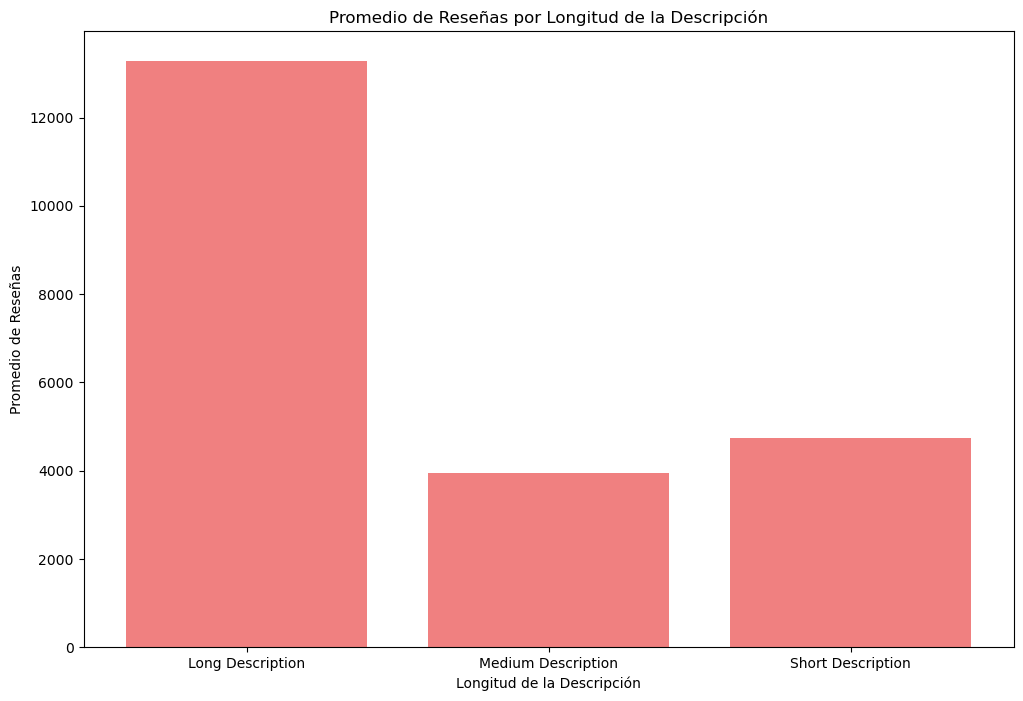

In [70]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating, AVG(review_count) AS avg_review_count
    FROM view_goodreads_authors_library
),
about_length AS (
    SELECT 
        CASE 
            WHEN LENGTH(about) > 1000 THEN 'Long Description'
            WHEN LENGTH(about) BETWEEN 500 AND 1000 THEN 'Medium Description'
            ELSE 'Short Description'
        END AS description_length,
        average_rate,
        review_count,
        (review_count / (review_count + avg_stats.avg_review_count)) * average_rate + 
        (avg_stats.avg_review_count / (review_count + avg_stats.avg_review_count)) * avg_stats.avg_rating AS weighted_rating
    FROM view_goodreads_authors_library, avg_stats
    WHERE about IS NOT NULL
)
SELECT 
    description_length,
    AVG(weighted_rating) AS avg_weighted_rating,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM about_length
GROUP BY description_length
ORDER BY author_count DESC;
"""

df = pd.read_sql(query, engine)

# Crear la gráfica de barras para el promedio de reseñas
plt.figure(figsize=(12, 8))
plt.bar(df['description_length'], df['avg_review_count'], color='lightcoral')
plt.xlabel('Longitud de la Descripción')
plt.ylabel('Promedio de Reseñas')
plt.title('Promedio de Reseñas por Longitud de la Descripción')
plt.savefig("../img/avg_reviews_by_description.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Número de Reseñas y Puntuación Promedio de los Autores

El scatterplot muestra la relación entre el número de reseñas (`review_count`) y la puntuación promedio (`average_rate`) de los autores en Goodreads. Cada punto en el gráfico representa a un autor.

### Observaciones

1. **Distribución General**: La mayoría de los autores tienen un número de reseñas relativamente bajo, con algunas excepciones que tienen un número muy alto de reseñas.
2. **Puntuación Promedio**: La puntuación promedio de los autores parece estar distribuida de manera uniforme en todo el rango de número de reseñas.
3. **Correlación**: No parece haber una correlación clara entre el número de reseñas y la puntuación promedio. Autores con muchas reseñas no necesariamente tienen una puntuación promedio más alta o más baja que aquellos con pocas reseñas.

### Conclusión

Este análisis sugiere que el número de reseñas que recibe un autor no está directamente relacionado con su puntuación promedio en Goodreads. Esto podría indicar que la calidad percibida de un autor (reflejada en la puntuación promedio) es independiente de su popularidad (reflejada en el número de reseñas).

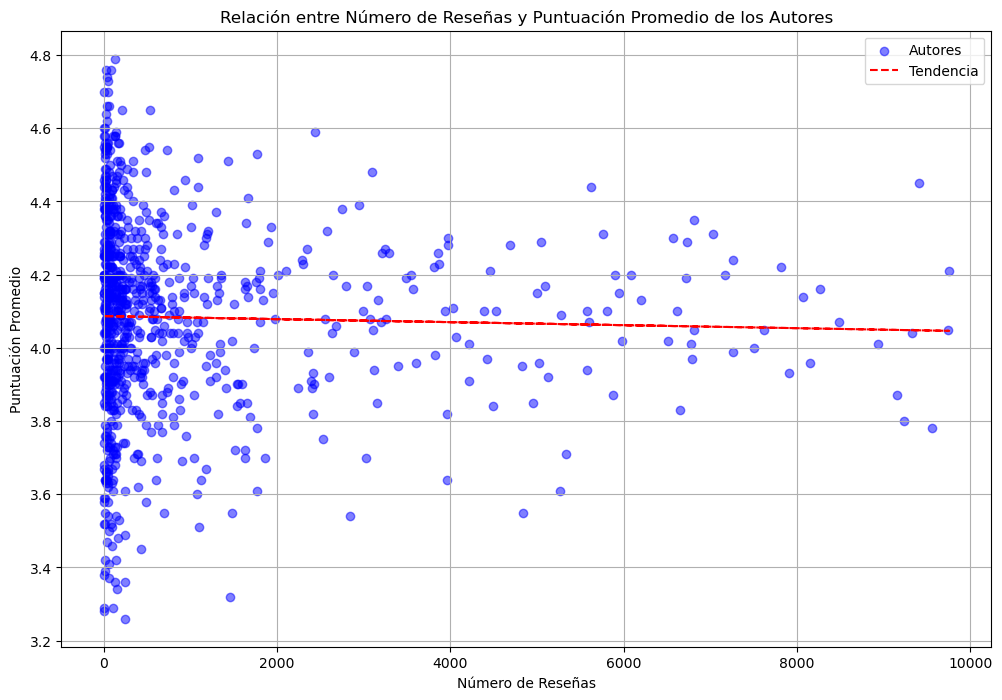

In [81]:
# Ejecutar la consulta SQL
query = """
SELECT 
    review_count,
    average_rate
FROM view_goodreads_authors_library
WHERE review_count IS NOT NULL AND review_count <= 10000
AND average_rate IS NOT NULL AND average_rate <= 5;
"""

df = pd.read_sql(query, engine)

# Crear el scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(df['review_count'], df['average_rate'], alpha=0.5, color='blue', label='Autores')

# Ajustar una línea de regresión lineal
z = np.polyfit(df['review_count'], df['average_rate'], 1)
p = np.poly1d(z)
plt.plot(df['review_count'], p(df['review_count']), color='red', linestyle='--', label='Tendencia')

plt.xlabel('Número de Reseñas')
plt.ylabel('Puntuación Promedio')
plt.title('Relación entre Número de Reseñas y Puntuación Promedio de los Autores')
plt.grid(True)
plt.legend()
plt.savefig("../img/reviews_vs_rating.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Número de Obras y Número de Fans de los Autores

El scatterplot muestra la relación entre el número de obras (`workcount`) y el número de fans (`fan_count`) de los autores en Goodreads. Cada punto en el gráfico representa a un autor.

### Observaciones

1. **Distribución General**: La mayoría de los autores tienen un número de obras relativamente bajo, con algunas excepciones que tienen un número muy alto de obras.
2. **Número de Fans**: La cantidad de fans varía ampliamente, pero parece haber una tendencia de que los autores con más obras tienden a tener más fans.
3. **Correlación**: Existe una correlación positiva entre el número de obras y el número de fans. Los autores que han publicado más obras tienden a tener más fans.

### Conclusión

Este análisis sugiere que la cantidad de obras publicadas por un autor está positivamente correlacionada con su popularidad en términos de número de fans en Goodreads. Esto podría indicar que los autores más prolíficos tienden a atraer a más seguidores.

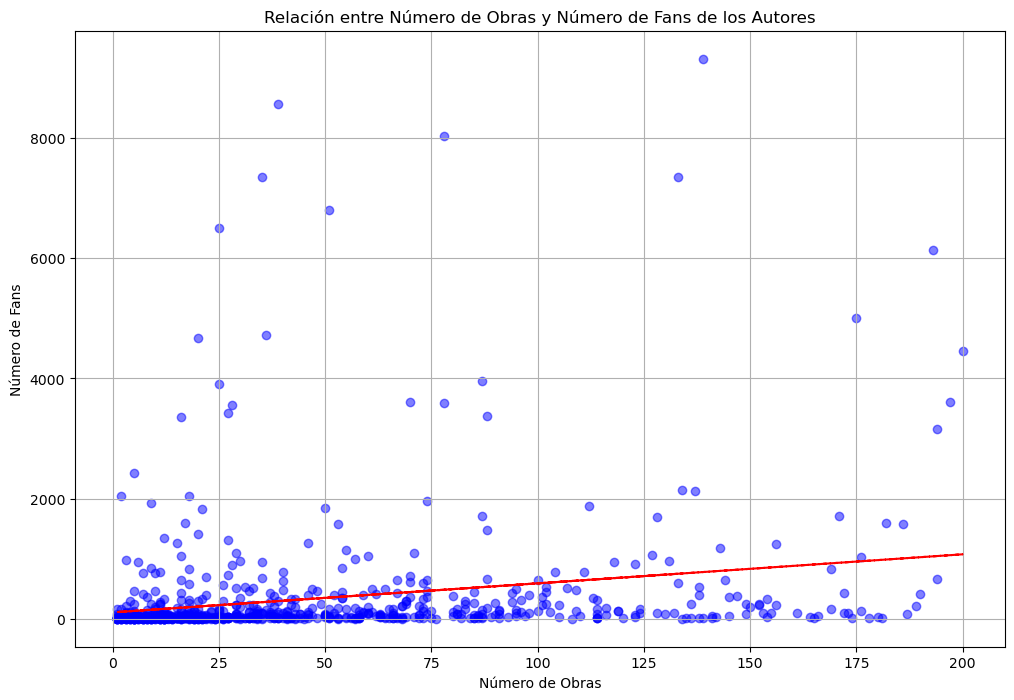

In [ ]:
# Ejecutar la consulta SQL
query = """
SELECT 
    workcount,
    fan_count
FROM view_goodreads_authors_library
WHERE workcount IS NOT NULL AND workcount != '' AND fan_count IS NOT NULL AND fan_count != ''
AND workcount <= 200 AND fan_count <= 10000;
"""

df = pd.read_sql(query, engine)

# Crear el scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(df['workcount'], df['fan_count'], alpha=0.5, color='blue' label='Autores')

# Ajustar una línea de regresión lineal
z = np.polyfit(df['workcount'], df['fan_count'], 1)
p = np.poly1d(z)
plt.plot(df['workcount'], p(df['workcount']), color='red', linestyle='--' label='Ajuste Lineal')

plt.xlabel('Número de Obras')
plt.ylabel('Número de Fans')
plt.title('Relación entre Número de Obras y Número de Fans de los Autores')
plt.grid(True)
plt.legend()
plt.savefig("../img/works_vs_fans.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Número de Obras y Puntuación Promedio de los Autores

El scatterplot muestra la relación entre el número de obras (`workcount`) y la puntuación promedio (`average_rate`) de los autores en Goodreads. Cada punto en el gráfico representa a un autor.

### Observaciones

1. **Distribución General**: La mayoría de los autores tienen un número de obras relativamente bajo, con algunas excepciones que tienen un número muy alto de obras.
2. **Puntuación Promedio**: La puntuación promedio de los autores parece estar distribuida de manera uniforme en todo el rango de número de obras.
3. **Correlación**: No parece haber una correlación clara entre el número de obras y la puntuación promedio. Autores con muchas obras no necesariamente tienen una puntuación promedio más alta o más baja que aquellos con pocas obras.

### Conclusión

Este análisis sugiere que el número de obras publicadas por un autor no está directamente relacionado con su puntuación promedio en Goodreads. Esto podría indicar que la calidad percibida de un autor (reflejada en la puntuación promedio) es independiente de su productividad (reflejada en el número de obras).

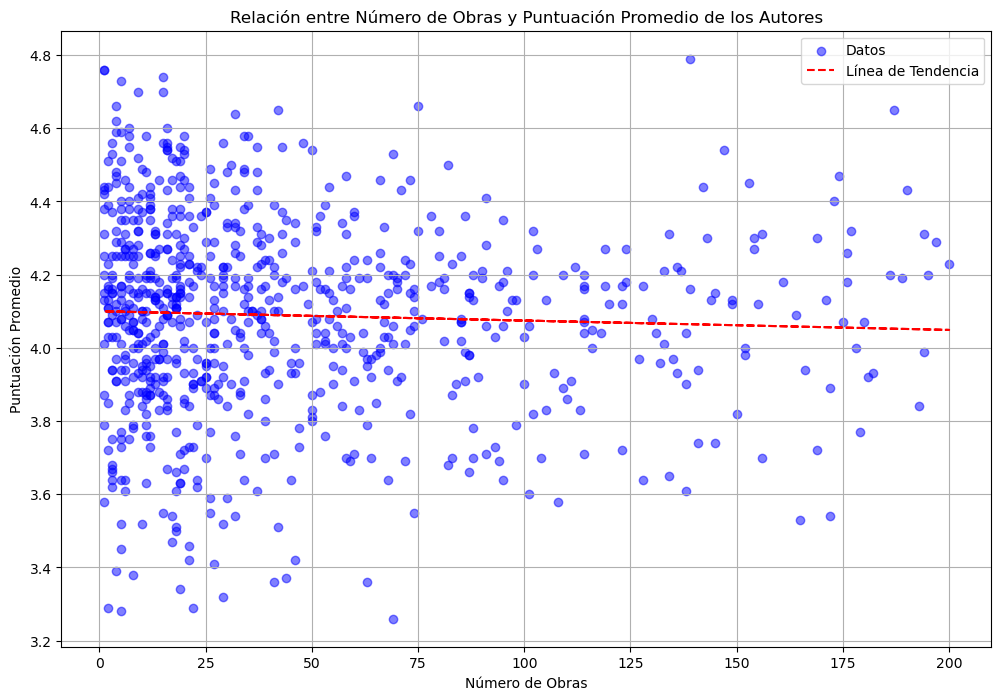

In [ ]:
import numpy as np

# Ejecutar la consulta SQL
query = """
SELECT 
    workcount,
    average_rate
FROM view_goodreads_authors_library
WHERE workcount IS NOT NULL AND workcount != '' AND workcount <= 200
AND average_rate IS NOT NULL AND average_rate <= 5;
"""

df = pd.read_sql(query, engine)

# Crear el scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(df['workcount'], df['average_rate'], alpha=0.5, color='blue', label='Autores')

# Ajustar una línea de regresión lineal
z = np.polyfit(df['workcount'], df['average_rate'], 1)
p = np.poly1d(z)
plt.plot(df['workcount'], p(df['workcount']), color='red', linestyle='--', label='Línea de Tendencia')

plt.xlabel('Número de Obras')
plt.ylabel('Puntuación Promedio')
plt.title('Relación entre Número de Obras y Puntuación Promedio de los Autores')
plt.grid(True)
plt.legend()
plt.savefig("../img/works_vs_rating.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Década de Nacimiento y Puntuación Promedio de los Autores

El gráfico de líneas muestra la relación entre las décadas de nacimiento de los autores y su puntuación promedio (`average_rate`) en Goodreads. Cada punto en el gráfico representa la puntuación promedio de los autores nacidos en una determinada década.

### Observaciones

1. **Distribución General**: La puntuación promedio de los autores varía a lo largo de las décadas.
2. **Tendencias Temporales**: Se pueden observar ciertas tendencias en la calidad percibida de los autores a lo largo del tiempo. Algunas décadas muestran un aumento en la puntuación promedio, mientras que otras muestran una disminución.
3. **Correlación**: No parece haber una correlación clara y consistente entre la década de nacimiento y la puntuación promedio. Sin embargo, se pueden identificar ciertos patrones y fluctuaciones en la calidad percibida de los autores a lo largo del tiempo.

### Conclusión

Este análisis sugiere que la calidad percibida de los autores, reflejada en la puntuación promedio, varía a lo largo del tiempo. Aunque no hay una correlación clara y consistente, se pueden observar ciertas tendencias y fluctuaciones en la calidad percibida de los autores nacidos en diferentes décadas. Esto podría indicar que factores históricos y culturales influyen en la percepción de la calidad de los autores en diferentes períodos de tiempo.

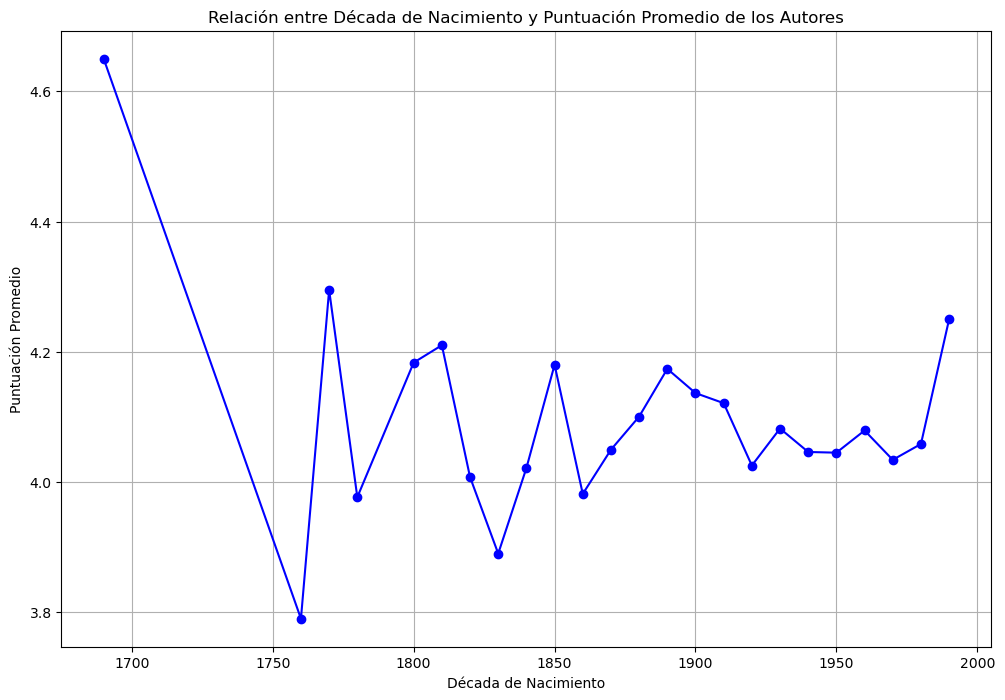

In [74]:
# Ejecutar la consulta SQL
query = """
WITH avg_stats AS (
    SELECT AVG(average_rate) AS avg_rating
    FROM view_goodreads_authors_library
),
author_decades AS (
    SELECT 
        FLOOR(YEAR(born) / 10) * 10 AS decade,
        average_rate
    FROM view_goodreads_authors_library
    WHERE born IS NOT NULL AND average_rate IS NOT NULL
)
SELECT 
    decade,
    AVG(average_rate) AS avg_weighted_rating,
    COUNT(*) AS author_count
FROM author_decades
GROUP BY decade
ORDER BY decade;
"""

df = pd.read_sql(query, engine)

# Crear el scatterplot
plt.figure(figsize=(12, 8))
plt.plot(df['decade'], df['avg_weighted_rating'], marker='o', linestyle='-', color='blue')
plt.xlabel('Década de Nacimiento')
plt.ylabel('Puntuación Promedio')
plt.title('Relación entre Década de Nacimiento y Puntuación Promedio de los Autores')
plt.grid(True)
plt.savefig("../img/decade_vs_rating.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Década de Nacimiento y Promedio de Reseñas de los Autores

El gráfico de líneas muestra la relación entre las décadas de nacimiento de los autores y el promedio de reseñas (`review_count`) en Goodreads. Cada punto en el gráfico representa el promedio de reseñas de los autores nacidos en una determinada década.

### Observaciones

1. **Distribución General**: El promedio de reseñas de los autores varía a lo largo de las décadas.
2. **Tendencias Temporales**: Se pueden observar ciertas tendencias en la popularidad de los autores a lo largo del tiempo. Algunas décadas muestran un aumento en el promedio de reseñas, mientras que otras muestran una disminución.
3. **Correlación**: No parece haber una correlación clara y consistente entre la década de nacimiento y el promedio de reseñas. Sin embargo, se pueden identificar ciertos patrones y fluctuaciones en la popularidad de los autores a lo largo del tiempo.

### Conclusión

Este análisis sugiere que la popularidad de los autores, reflejada en el promedio de reseñas, varía a lo largo del tiempo. Aunque no hay una correlación clara y consistente, se pueden observar ciertas tendencias y fluctuaciones en la popularidad de los autores nacidos en diferentes décadas. Esto podría indicar que factores históricos y culturales influyen en la percepción de la popularidad de los autores en diferentes períodos de tiempo.

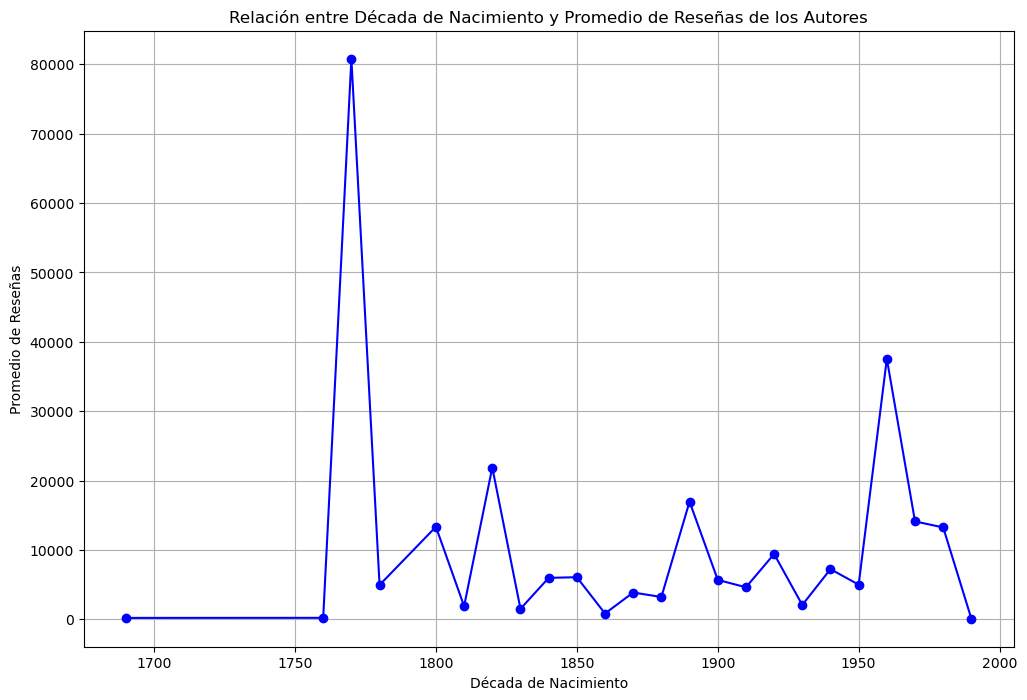

In [75]:
# Ejecutar la consulta SQL
query = """
WITH author_decades AS (
    SELECT 
        FLOOR(YEAR(born) / 10) * 10 AS decade,
        review_count
    FROM view_goodreads_authors_library
    WHERE born IS NOT NULL AND review_count IS NOT NULL
)
SELECT 
    decade,
    AVG(review_count) AS avg_review_count,
    COUNT(*) AS author_count
FROM author_decades
GROUP BY decade
ORDER BY decade;
"""

df = pd.read_sql(query, engine)

# Crear el gráfico de líneas
plt.figure(figsize=(12, 8))
plt.plot(df['decade'], df['avg_review_count'], marker='o', linestyle='-', color='blue')
plt.xlabel('Década de Nacimiento')
plt.ylabel('Promedio de Reseñas')
plt.title('Relación entre Década de Nacimiento y Promedio de Reseñas de los Autores')
plt.grid(True)
plt.savefig("../img/decade_vs_reviews.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Década de Nacimiento y Promedio de Fans de los Autores

El gráfico de líneas muestra la relación entre las décadas de nacimiento de los autores y el promedio de fans (`fan_count`) en Goodreads. Cada punto en el gráfico representa el promedio de fans de los autores nacidos en una determinada década.

### Observaciones

1. **Distribución General**: El promedio de fans de los autores varía a lo largo de las décadas.
2. **Tendencias Temporales**: Se pueden observar ciertas tendencias en la popularidad de los autores a lo largo del tiempo. Algunas décadas muestran un aumento en el promedio de fans, mientras que otras muestran una disminución.
3. **Correlación**: No parece haber una correlación clara y consistente entre la década de nacimiento y el promedio de fans. Sin embargo, se pueden identificar ciertos patrones y fluctuaciones en la popularidad de los autores a lo largo del tiempo.

### Conclusión

Este análisis sugiere que la popularidad de los autores, reflejada en el promedio de fans, varía a lo largo del tiempo. Aunque no hay una correlación clara y consistente, se pueden observar ciertas tendencias y fluctuaciones en la popularidad de los autores nacidos en diferentes décadas. Esto podría indicar que factores históricos y culturales influyen en la percepción de la popularidad de los autores en diferentes períodos de tiempo.

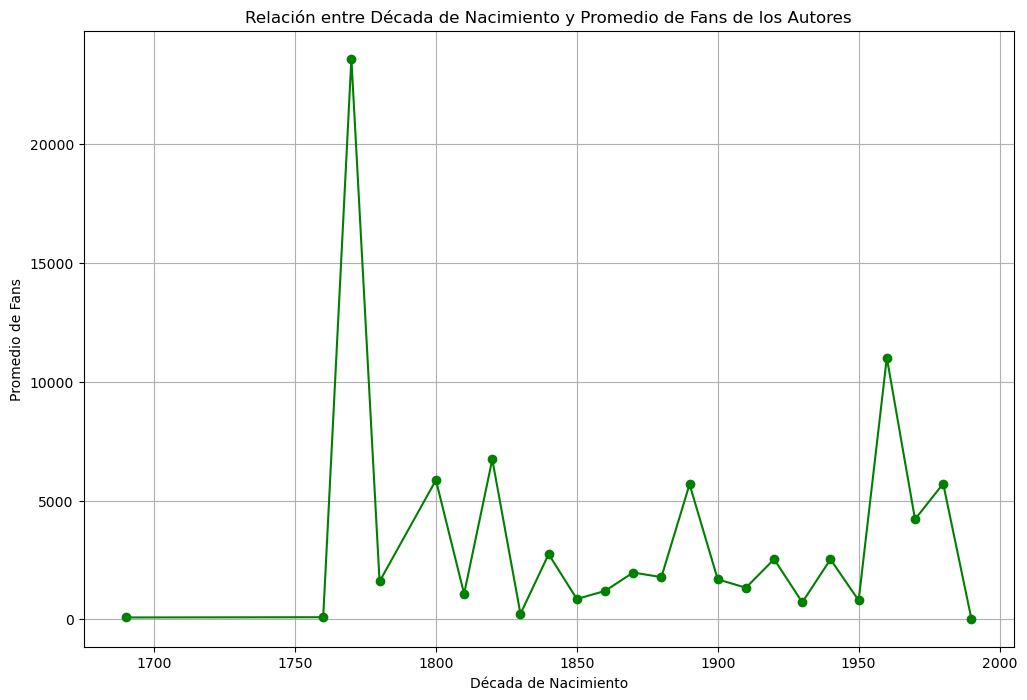

In [76]:
# Ejecutar la consulta SQL
query = """
WITH author_decades AS (
    SELECT 
        FLOOR(YEAR(born) / 10) * 10 AS decade,
        fan_count
    FROM view_goodreads_authors_library
    WHERE born IS NOT NULL AND fan_count IS NOT NULL
)
SELECT 
    decade,
    AVG(fan_count) AS avg_fan_count,
    COUNT(*) AS author_count
FROM author_decades
GROUP BY decade
ORDER BY decade;
"""

df = pd.read_sql(query, engine)

# Crear el gráfico de líneas
plt.figure(figsize=(12, 8))
plt.plot(df['decade'], df['avg_fan_count'], marker='o', linestyle='-', color='green')
plt.xlabel('Década de Nacimiento')
plt.ylabel('Promedio de Fans')
plt.title('Relación entre Década de Nacimiento y Promedio de Fans de los Autores')
plt.grid(True)
plt.savefig("../img/decade_vs_fans.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Década de Nacimiento y Promedio de Obras de los Autores

El gráfico de líneas muestra la relación entre las décadas de nacimiento de los autores y el promedio de obras (`workcount`) en Goodreads. Cada punto en el gráfico representa el promedio de obras de los autores nacidos en una determinada década.

### Observaciones

1. **Distribución General**: El promedio de obras de los autores varía a lo largo de las décadas.
2. **Tendencias Temporales**: Se pueden observar ciertas tendencias en la productividad de los autores a lo largo del tiempo. Algunas décadas muestran un aumento en el promedio de obras, mientras que otras muestran una disminución.
3. **Correlación**: No parece haber una correlación clara y consistente entre la década de nacimiento y el promedio de obras. Sin embargo, se pueden identificar ciertos patrones y fluctuaciones en la productividad de los autores a lo largo del tiempo.

### Conclusión

Este análisis sugiere que la productividad de los autores, reflejada en el promedio de obras, varía a lo largo del tiempo. Aunque no hay una correlación clara y consistente, se pueden observar ciertas tendencias y fluctuaciones en la productividad de los autores nacidos en diferentes décadas. Esto podría indicar que factores históricos y culturales influyen en la productividad de los autores en diferentes períodos de tiempo.

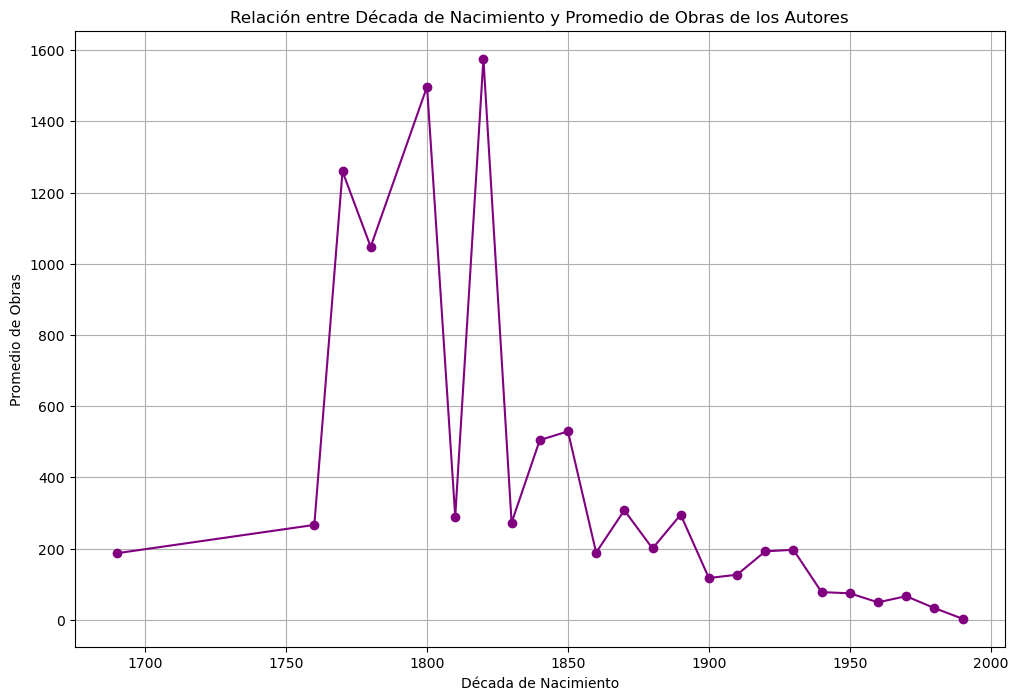

In [77]:
# Ejecutar la consulta SQL
query = """
WITH author_decades AS (
    SELECT 
        FLOOR(YEAR(born) / 10) * 10 AS decade,
        workcount
    FROM view_goodreads_authors_library
    WHERE born IS NOT NULL AND workcount IS NOT NULL
)
SELECT 
    decade,
    AVG(workcount) AS avg_workcount,
    COUNT(*) AS author_count
FROM author_decades
GROUP BY decade
ORDER BY decade;
"""

df = pd.read_sql(query, engine)

# Crear el gráfico de líneas
plt.figure(figsize=(12, 8))
plt.plot(df['decade'], df['avg_workcount'], marker='o', linestyle='-', color='purple')
plt.xlabel('Década de Nacimiento')
plt.ylabel('Promedio de Obras')
plt.title('Relación entre Década de Nacimiento y Promedio de Obras de los Autores')
plt.grid(True)
plt.savefig("../img/decade_vs_works.jpg", dpi=300, bbox_inches='tight')
plt.show()